In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Генерация синтетического датасета

In [2]:
from faker import Faker
import random
import math

np.random.seed(101)
random.seed(101)
Faker.seed(101)


fake = Faker("ru_RU")

USERS_TO_GENERATE = 7500

local_partners = {
    "Новосибирск": [
        {"name": "Крафтовая кофейня Новосиб", "category": "Кофейни и Бары"},
        {"name": "Экипировка 'Блестящие снасти'", "category": "Охота и Рыбалка"},
        {"name": "Автозапчасти V9", "category": "Автотовары"},
        {"name": "Спортклуб 'Медведь'", "category": "Спорт и Фитнесс"},
    ],
    "Красноярск": [
        {"name": "Бар 'Столбы'", "category": "Кофейни и Бары"},
        {"name": "Магазин 'Тайга'", "category": "Охота и Рыбалка"},
        {"name": "Автосервис 'Енисей Авто'", "category": "Автотовары"},
    ],
    "Омск": [
        {"name": "Кофейня 'Омский кофе'", "category": "Кофейни и Бары"},
        {"name": "Магазин 'Рыбалка на Иртыше'", "category": "Охота и Рыбалка"},
        {"name": "Мир Обоев", "category": "Дом и Ремонт"},
    ],
    "Сургут": [
        {"name": "Паб 'Серьезный Мужик'", "category": "Кофейни и Бары"},
        {"name": "Спецодежда и снасти", "category": "Охота и Рыбалка"},
        {"name": "Тренажерный зал уникальный для Сургута", "category": "Спорт и Фитнесс"},
    ],
}

cities = list(local_partners.keys())
industries = ["Нефтегаз", "Завод", "IT", "Услуги", "Бюджетники", "Ритейл"]

# Категории магазинов
categories = ["Автотовары", "Охота и Рыбалка", "Кофейни и Бары", "Спорт и Фитнесс", "Дом и Ремонт"]

data = []


for _ in range(USERS_TO_GENERATE):
    user_id = fake.uuid4()
    age = int(np.random.normal(loc=35, scale=10))
    age = max(18, min(age, 65))

    city = random.choice(cities)
    industry = random.choice(industries)

    # Доходы - математическое ожидание и отклонение
    base_income = {
        "IT": 150000, "Нефтегаз": 140000, 
        "Завод": 85000, "Ритейл": 70000, "Услуги": 50000, "Бюджетники": 45000
    }
    income_scale = {
        "IT": 20000, "Нефтегаз": 20000, 
        "Завод": 12000, "Ритейл": 10000, "Услуги": 8000, "Бюджетники": 8000
    }
    
    income = int(np.random.normal(loc=base_income[industry], scale=income_scale[industry]))
    income = max(30000, income)

    # Процент вывода - математическое ожидание и отклонение
    base_drain = {
        "IT": 60, "Нефтегаз": 63, 
        "Завод": 87, "Ритейл": 90, "Услуги": 95, "Бюджетники": 96
    }
    drain_scale = {
        "IT": 8, "Нефтегаз": 8, 
        "Завод": 6, "Ритейл": 5, "Услуги": 3, "Бюджетники": 2
    }
    
    drain_percent = np.random.normal(loc=base_drain[industry], scale=drain_scale[industry])
    drain_percent = max(40, min(drain_percent, 100))

    stores_in_city = local_partners[city]
    city_categories = list(set([s["category"] for s in stores_in_city]))
    
    # В 85% случаев интерес клиента совпадает с чем-то из локальных магазинов
    if random.random() < 0.85:
        historical_top_category = random.choice(city_categories)
    else:
        historical_top_category = random.choice(categories)

    proposed_store = random.choice(stores_in_city)
    proposed_store_name = proposed_store["name"]
    proposed_store_category = proposed_store["category"]

    is_remote_worker = 1 if industry in ("Нефтегаз", "Завод") and city == "Сургут" else 0
    
    # Изначально человек не хочет ничего удерживать
    score = -1.5

    # Если угадали категорию, вероятность сильно повышается
    if historical_top_category == proposed_store_category:
        score += 2.5 
    
    if is_remote_worker == 1:
        score += 2.0
        
    # я бы сейчас тоже от кофе не отказался
    if industry == "IT" and proposed_store_category == "Кофейни и Бары":
        score += 1.5
        
    # работяги должны ценить полезные вещи
    if industry in ("Завод", "Нефтегаз") and proposed_store_category in ("Охота и Рыбалка", "Автотовары", "Дом и Ремонт"):
        score += 1.5

    # Превращаем скор в вероятность от 0 до 1, используя сигмоиду
    probability = 1 / (1 + math.exp(-score))

    target_retained = np.random.binomial(1, probability)
    
    data.append([
        user_id, age, city, industry, income, is_remote_worker, drain_percent, 
        historical_top_category, proposed_store_name, proposed_store_category, target_retained
    ])

columns = ["user_id", "age", "city", "industry", "income", "is_remote_worker", "current_drain_percent", "historical_top_category", "proposed_store_name", "proposed_store_category", "target_retained_40_percent"]

df = pd.DataFrame(data, columns=columns)
df_to_classifier = df.copy()

df[df["target_retained_40_percent"] == 1]

,user_id,age,city,industry,income,is_remote_worker,current_drain_percent,historical_top_category,proposed_store_name,proposed_store_category,target_retained_40_percent
2,80e6b5d0-a9d9-4650-8c6b-df0d7796668d,18,Красноярск,IT,164802,0,64.230508,Автотовары,Магазин 'Тайга',Охота и Рыбалка,1
3,eae3732d-38c1-45d6-9a1f-7aa536eafa28,29,Красноярск,Завод,82982,0,86.351596,Охота и Рыбалка,Магазин 'Тайга',Охота и Рыбалка,1
4,c87383f4-b142-4de1-bc47-571849dc9b34,25,Красноярск,Услуги,57640,0,95.572383,Автотовары,Автосервис 'Енисей Авто',Автотовары,1
5,701f9706-f89a-4643-943b-cd04365e52e7,54,Сургут,Услуги,47815,0,94.052301,Кофейни и Бары,Спецодежда и снасти,Охота и Рыбалка,1
6,293ba8b9-317b-4b86-8157-89161202d125,61,Омск,Завод,93202,0,88.815993,Охота и Рыбалка,Мир Обоев,Дом и Ремонт,1
...,...,...,...,...,...,...,...,...,...,...,...
7486,f9fd513d-6c97-4e4a-99b1-1b9a430bf900,18,Красноярск,Завод,89366,0,87.191137,Охота и Рыбалка,Бар 'Столбы',Кофейни и Бары,1
7488,6ac52ce2-dc1c-4e1d-b0b9-0ac505aac0c8,22,Омск,Услуги,47503,0,92.469122,Дом и Ремонт,Мир Обоев,Дом и Ремонт,1
7492,7f44b0f8-e3cf-4bd6-9d79-45b7fb3b47c3,27,Новосибирск,Услуги,60174,0,95.700324,Спорт и Фитнесс,Спортклуб 'Медведь',Спорт и Фитнесс,1
7493,ac3e7e0a-df6d-47e8-a4a5-7cd5d86ca0ab,39,Новосибирск,IT,159873,0,53.714675,Автотовары,Автозапчасти V9,Автотовары,1


## 2. Кластеризация

Выделю признаки, по которым буду проводить кластеризацию.

In [3]:
sns.set_theme(style="whitegrid")

clustering_features = ["age", "income", "current_drain_percent"]
X = df[clustering_features]
X.head()

,age,income,current_drain_percent
0,62,50025,97.815939
1,40,47501,97.111297
2,18,164802,64.230508
3,29,82982,86.351596
4,25,57640,95.572383


Стандартизирую данные. Через StandardScaler приведу их к распределению со средним = 0, отклонением = 1.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(X, columns=scaler.get_feature_names_out())

X.head()

,age,income,current_drain_percent
0,2.856936,-0.923264,1.017996
1,0.563503,-0.981308,0.973151
2,-1.729929,1.716228,-1.119458
3,-0.583213,-0.165362,0.288379
4,-1.000201,-0.748144,0.875211


Определю количество кластеров при помощи метода Локтя.

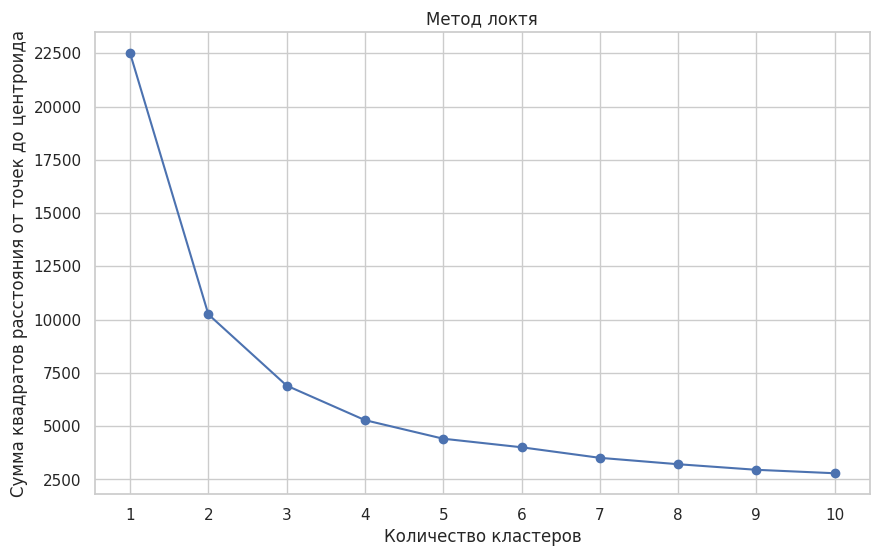

In [5]:
from sklearn.cluster import KMeans

# Функция, реализующая метод локтя
def plot_elbow(dataset, k):
    if (k <= 0):
        return
    
    metric_values = []

    for clusters_amount in range(1, k+1):
        kmeans = KMeans(clusters_amount, random_state=101)
        model = kmeans.fit(dataset)
        metric_values.append(model.inertia_)

    plt.figure(figsize=(10,6))
    plt.plot(range(1, k+1), metric_values, marker="o")
    plt.ylabel("Сумма квадратов расстояния от точек до центроида")
    plt.xlabel("Количество кластеров")
    plt.title("Метод локтя")
    plt.xticks(range(1, k+1))
    plt.show()

plot_elbow(X, 10)

Очень сильное падение на переходе к двум кластерам. Присутсвует небольшое падение на 3. 2 или 3 кластера.

Теперь попробую использовать метод Силуэта.

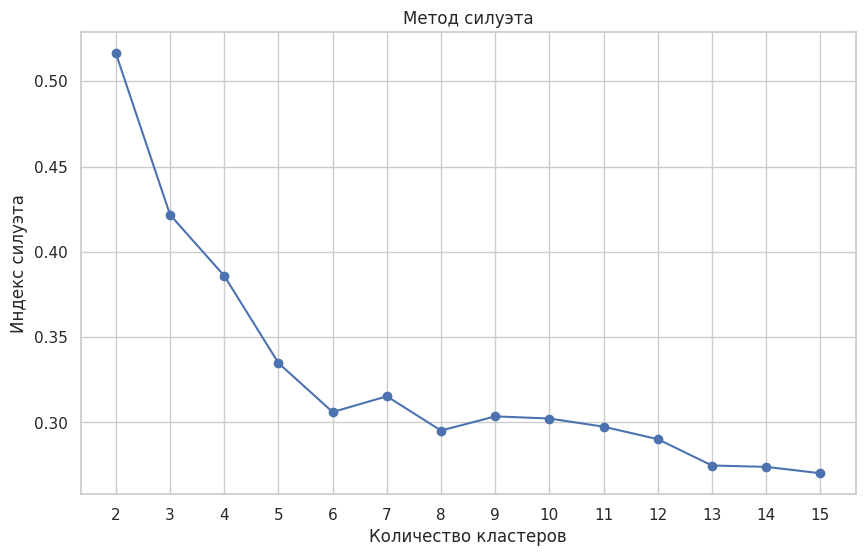

In [6]:
from sklearn.metrics import silhouette_score

def plot_silhouette(dataset, k):
    if (k <= 1):
        return
    
    silhouette_scores = []
    for clusters_amount in range(2, k+1):
        k_means = KMeans(clusters_amount, random_state=101)
        cluster_labels = k_means.fit_predict(dataset)
        silhouette_scores.append(silhouette_score(dataset, cluster_labels))

    plt.figure(figsize=(10,6))
    plt.plot(range(2, k+1), silhouette_scores, marker="o")
    plt.xticks(range(2, k+1))
    plt.title("Метод силуэта")
    plt.xlabel("Количество кластеров")
    plt.ylabel("Индекс силуэта")
    plt.show()

plot_silhouette(X, 15)

Самый высокий индекс при разбиении на 2 кластера. При переходе на 3, он серьезно падает.

Буду проводить разбиение на 2 кластера.

In [7]:
kmeans = KMeans(n_clusters=2, random_state=101, n_init=10)

cluster_labels = kmeans.fit_predict(X)
df["cluster_label"] = cluster_labels

cluster_summary = df.groupby("cluster_label")[clustering_features].mean().round(1)

cluster_summary["count"] = df["cluster_label"].value_counts()

print("Средние значения по выделенным кластерам:")
cluster_summary

Средние значения по выделенным кластерам:


,age,income,current_drain_percent,count
cluster_label,,,,
0,34.8,62538.2,92.0,4988
1,34.2,145045.6,61.6,2512


Наблюдаем 2 кластера:
- 0 кластер (*Транзитеры*): выводят почти все деньги сразу. Зачастую, это клиенты, получающие небольшую ЗП.
- 1 кластер (*Держут деньги*): оставляют часть денег на карте. Обычно, это клиенты с большой ЗП.

Присвою каждой записи в датафрейме имя кластера.

In [8]:
def name_cluster(row):
    if row["current_drain_percent"] >= 92:
        return "Транзитер"
    else:
        return "Держит деньги"

In [9]:
cluster_names = cluster_summary.apply(name_cluster, axis=1).to_dict()

df["cluster_name"] = df["cluster_label"].map(cluster_names)

df.head()

,user_id,age,city,industry,income,is_remote_worker,current_drain_percent,historical_top_category,proposed_store_name,proposed_store_category,target_retained_40_percent,cluster_label,cluster_name
0,e88b7591-31db-4e32-98dc-b35f94c662cd,62,Красноярск,Бюджетники,50025,0,97.815939,Спорт и Фитнесс,Бар 'Столбы',Кофейни и Бары,0,0,Транзитер
1,5bd21b6a-ec89-47a6-8a0a-c984f71ab247,40,Красноярск,Бюджетники,47501,0,97.111297,Кофейни и Бары,Магазин 'Тайга',Охота и Рыбалка,0,0,Транзитер
2,80e6b5d0-a9d9-4650-8c6b-df0d7796668d,18,Красноярск,IT,164802,0,64.230508,Автотовары,Магазин 'Тайга',Охота и Рыбалка,1,1,Держит деньги
3,eae3732d-38c1-45d6-9a1f-7aa536eafa28,29,Красноярск,Завод,82982,0,86.351596,Охота и Рыбалка,Магазин 'Тайга',Охота и Рыбалка,1,0,Транзитер
4,c87383f4-b142-4de1-bc47-571849dc9b34,25,Красноярск,Услуги,57640,0,95.572383,Автотовары,Автосервис 'Енисей Авто',Автотовары,1,0,Транзитер


Составлю диаграмму рассеивания. Выделенеие - по именам кластеров.

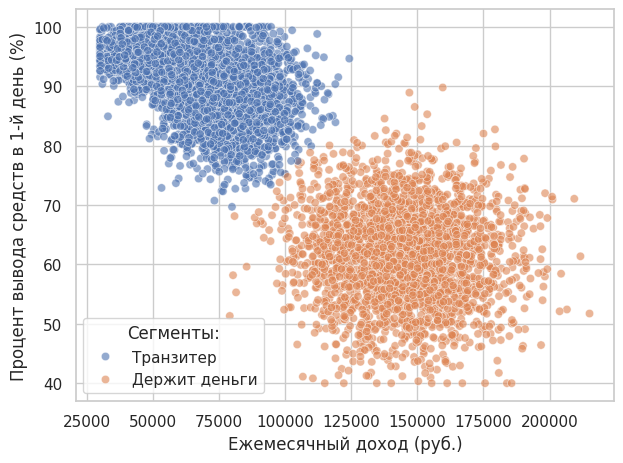

In [10]:
sns.scatterplot(
    data=df,
    x="income",
    y="current_drain_percent",
    hue="cluster_name",
    alpha=0.6
)

# Кластеризация клиентов\nПаттерны перевода зарплат
plt.xlabel("Ежемесячный доход (руб.)")
plt.ylabel("Процент вывода средств в 1-й день (%)")
plt.legend(title = "Сегменты:")
plt.tight_layout()

plt.show()

**Сегмент "Транзитеры" (синие точки):**
Люди со средним и низким доходом (в основном от 30к до 100к руб.). Работники бюджетной сферы, ритейла и услуг.

Они выводят почти всю зарплату в первый же день (от 75% до 100%).

Главная целевая аудитория для новой фичи. Именно их мы должны "заякорить" уникальными локальными партнерами, чтобы они перестали быть транзитерами.

**Сегмент "Держит деньги" (оранжевые точки):**
Клиенты с доходом выше среднего (от 100к до 200к+ руб.). IT-сектор, Нефтегаз и крупные заводы.

Оставляют на картах значительную часть средств (выводят от 40% до 75%).

Для них эта фича станет отличным инструментом лояльности, поощряя их текущее поведение и не давая конкурентам переманить их агрессивным кэшбеком.

График доказывает, что сгенерированные синтетические данные абсолютно логичны с точки зрения экономики.

## 3. Предсказать вероятность удержания средств

Обучу модель, которая будет предсказывать вероятность удержания клиентом денежных средств на карте.

В качестве модели для обучения буду использовать CatBoost т.к. он не требует особой обработки данных перед обучением, самостоятельно кодирует категориальные данные.

Датасет разделю на 3 части: Train, Validation и Test.

In [11]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

features = ["age", "city", "industry", "income", "current_drain_percent", "is_remote_worker", "historical_top_category", "proposed_store_name", "proposed_store_category"]
target = "target_retained_40_percent"


X = df_to_classifier[features]
y = df_to_classifier[target]

categorical_features = ["city", "industry", "historical_top_category", "proposed_store_name", "proposed_store_category"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=101, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=101, stratify=y_temp)

Для подбора гиперпараметров модели на валидационном датасете буду использовать `Optuna`. Подбирать буду глубину деревьев, learning rate, и l2 регуляризацию.

Буду максимизировать метрику AUC на валидационном датасете.

In [12]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial: optuna.Trial):
    learning_rate = trial.suggest_float("learning_rate", 0.001, 0.2, log=True)
    depth = trial.suggest_int("depth", 3, 8)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10, log=True)

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        cat_features=categorical_features,
        auto_class_weights="Balanced",
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=101,
        verbose=False
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds_probability = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, preds_probability)

    return auc

/home/nikita/Documents/hackathons/1_Sber/sber-hak/model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from optuna.samplers import TPESampler

sampler = TPESampler(seed=101)

study = optuna.create_study(study_name="CatBoost HPO", direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=100)

print("Лучшие гиперпараметры:", study.best_params)
print("Лучший ROC-AUC:", study.best_value)

[I 2026-04-10 10:39:28,046] A new study created in memory with name: CatBoost HPO


[I 2026-04-10 10:39:30,576] Trial 0 finished with value: 0.7997864081395125 and parameters: {'learning_rate': 0.015425836789242569, 'depth': 6, 'l2_leaf_reg': 1.0677614235804835}. Best is trial 0 with value: 0.7997864081395125.
[I 2026-04-10 10:39:32,547] Trial 1 finished with value: 0.7940964872452406 and parameters: {'learning_rate': 0.002481284004432276, 'depth': 7, 'l2_leaf_reg': 6.821766698437828}. Best is trial 0 with value: 0.7997864081395125.
[I 2026-04-10 10:39:33,420] Trial 2 finished with value: 0.799196472536819 and parameters: {'learning_rate': 0.005085556447072269, 'depth': 8, 'l2_leaf_reg': 5.266764041303843}. Best is trial 0 with value: 0.7997864081395125.
[I 2026-04-10 10:39:34,146] Trial 3 finished with value: 0.7970109929463527 and parameters: {'learning_rate': 0.002735616603515917, 'depth': 6, 'l2_leaf_reg': 2.2497380520068404}. Best is trial 0 with value: 0.7997864081395125.
[I 2026-04-10 10:39:34,892] Trial 4 finished with value: 0.795055732127669 and parameters: 

Лучшие гиперпараметры: {'learning_rate': 0.1622907349538086, 'depth': 8, 'l2_leaf_reg': 2.377107451513059}
Лучший ROC-AUC: 0.8101990113382745


Обучу финальную модель с гиперпараметрами, полученными самой удачной моделью на валидации.

In [19]:
from sklearn.metrics import classification_report

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1622907349538086,
    depth=8,
    l2_leaf_reg=2.377107451513059,
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    early_stopping_rounds=50,
    random_seed=101,
    verbose=100
)

model.fit(X_train, y_train)

0:	learn: 0.6831595	total: 8.81ms	remaining: 4.4s
100:	learn: 0.3709369	total: 666ms	remaining: 2.63s
200:	learn: 0.2702926	total: 1.32s	remaining: 1.97s
300:	learn: 0.1973979	total: 1.99s	remaining: 1.31s
400:	learn: 0.1485391	total: 2.67s	remaining: 659ms
499:	learn: 0.1153113	total: 3.34s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['city', 'industry', 'historical_top_category', 'proposed_store_name', 'proposed_store_category'], depth=8, early_stopping_rounds=50, iterations=500, l2_leaf_reg=2.377107451513059, learning_rate=0.1622907349538086, random_seed=101, verbose=100)

In [20]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       624
           1       0.72      0.67      0.70       501

    accuracy                           0.74      1125
   macro avg       0.74      0.73      0.73      1125
weighted avg       0.74      0.74      0.74      1125



Ниже напишу рекомендательную систему, в которой уже будет реализована обученная мною модель.

### Рекомендация магазинов с элементом рандома

Чтобы алгоритм был умным, а не тупым, бонусный магазин должен выбираться неслучайно.

Проблема: условному автолюбителю практически всегда будут выдаваться бонусы на магазины с автотоварами.

Решение: ввести элемент рандома в выбор магазина

In [16]:
def recommend_store_with_exploration(user_data, available_stores, model, epsilon=0.2):
    """
    Перебирает все магазины для пользователя и рекомендует самый интересный для него.

    С вероятностью `epsilon` может выдать магазин из другой случайной категории.
    """

    user_df = pd.DataFrame([user_data] * len(available_stores))

    user_df["proposed_store_name"] = [store["name"] for store in available_stores]
    user_df["proposed_store_category"] = [store["category"] for store in available_stores]

    probabilities = model.predict_proba(user_df)[:, 1]

    results = []
    for i, store in enumerate(available_stores):
        results.append({
            "name": store["name"],
            "category": store["category"],
            "probability": probabilities[i]
        })
    
    results = sorted(results, key=lambda x: x["probability"], reverse=True)

    if np.random.rand() > epsilon:
        chosen = results[0]
        chosen_strategy = "AI top match"
    else:
        pool = results[1:4] if len(results) > 3 else results[1:]
        chosen = random.choice(pool)
        chosen_strategy = "random"
    
    return chosen["name"], chosen["category"], chosen["probability"], chosen_strategy

Ниже показан пример работы алгоритма на случайном клиенте из Test датасета.

In [17]:
sample_client = X_test.iloc[213].drop(["proposed_store_name", "proposed_store_category"]).to_dict()
client_city = sample_client["city"]

for i in range(5):
    name, category, probability, strategy = recommend_store_with_exploration(sample_client, local_partners[client_city], model)
    print(f"[Попытка {i+1}]: {strategy}: ({name} - {category}), вероятность удержания ЗП: {probability:.1%}")

[Попытка 1]: AI top match: (Паб 'Серьезный Мужик' - Кофейни и Бары), вероятность удержания ЗП: 75.9%
[Попытка 2]: AI top match: (Паб 'Серьезный Мужик' - Кофейни и Бары), вероятность удержания ЗП: 75.9%
[Попытка 3]: AI top match: (Паб 'Серьезный Мужик' - Кофейни и Бары), вероятность удержания ЗП: 75.9%
[Попытка 4]: random: (Спецодежда и снасти - Охота и Рыбалка), вероятность удержания ЗП: 25.0%
[Попытка 5]: AI top match: (Паб 'Серьезный Мужик' - Кофейни и Бары), вероятность удержания ЗП: 75.9%


## 4. Проанализировать региональные признаки для персонализации предложений

Проанализирую региональные признаки для персонализации предложений путем выделения самых важных признаков из обученного мною классификатора.

/tmp/ipykernel_13053/3725559678.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')


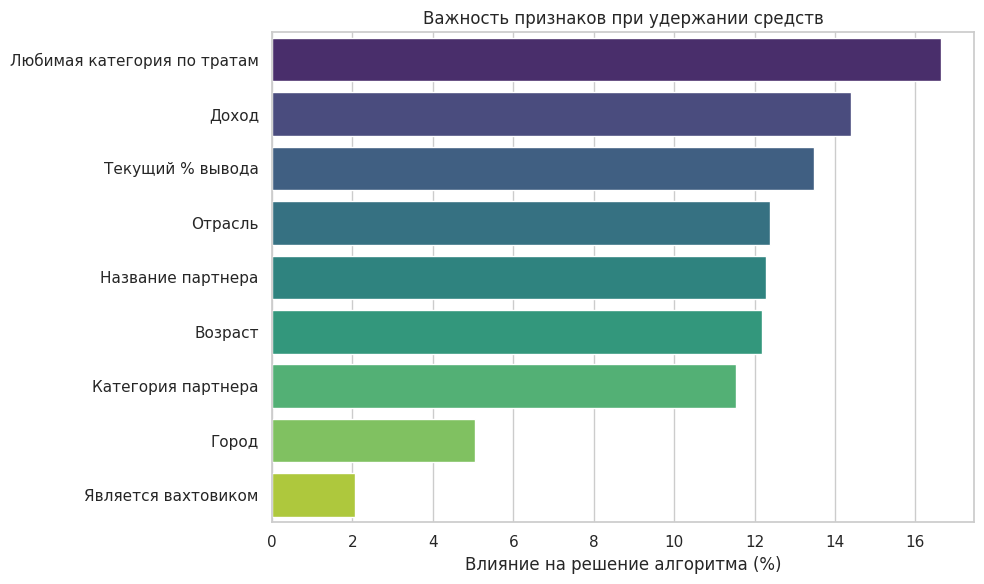

In [18]:
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False)

fi_df['feature'] = fi_df['feature'].replace({
    'historical_top_category': 'Любимая категория по тратам',
    'proposed_store_category': 'Категория партнера',
    'proposed_store_name': 'Название партнера',
    'current_drain_percent': 'Текущий % вывода',
    'income': 'Доход',
    'age': 'Возраст',
    'city': 'Город',
    'industry': 'Отрасль',
    "is_remote_worker": "Является вахтовиком"
})

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков при удержании средств')
plt.xlabel('Влияние на решение алгоритма (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()